Initialized new Q table
Starting Q-Learning training for 5000 episodes...
  Episode 500/5000 completed
  Episode 1000/5000 completed
  Episode 1500/5000 completed
  Episode 2000/5000 completed
  Episode 2500/5000 completed
  Episode 3000/5000 completed
  Episode 3500/5000 completed
  Episode 4000/5000 completed
  Episode 4500/5000 completed
  Episode 5000/5000 completed
Saved Q table to artifacts\q_bis_deltabis_agent.npz
Saved last episode traces to artifacts\q_bis_deltabis_last_episode.npz


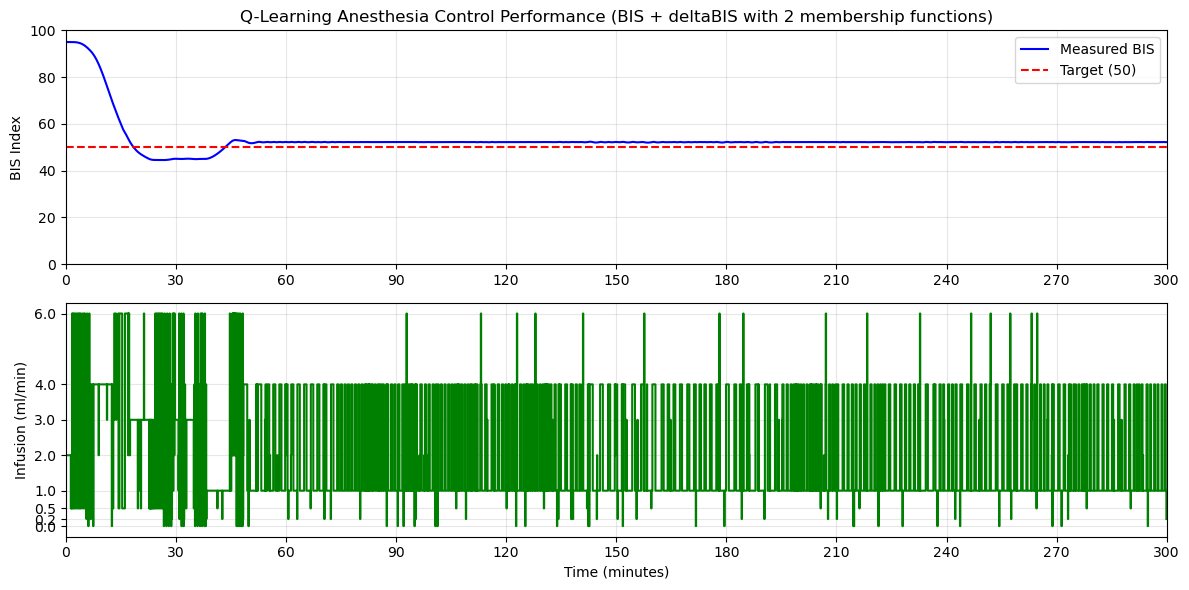

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

TARGET_BIS = 50.0
EPISODES = 5000
STEPS_PER_EP = 3600
DT = 5 / 60              # Time step in minutes (5 seconds)
ALPHA = 0.2              # Learning rate
GAMMA = 0.69             # Discount factor
EPSILON = 0.05           # Exploration rate

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1, ke0 = 4.27, 0.17
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**2  # 100 states (BIS error x delta-BIS, each with 10 bins)

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]  # Seconds
RANDOM_SEED = 42

AGE_GROUPS = {
    '25-29': (25, 29),
    '30-45': (30, 45),
    '46-60': (46, 60),
    '60-80': (60, 80),
    '80+': (80, 120)
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

Q_PATH = ARTIFACTS_DIR / "q_agent_bis_deltabis.npz"
TRACE_PATH = ARTIFACTS_DIR / "q_agent_bis_deltabis_last_episode.npz"

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_fuzzy_features(bis_error, deltabis):
    """Fuzzification using 2 membership functions: negative and positive.
    
    Args:
        bis_error: BIS error (current - target)
        deltabis: Change in BIS (BIS(t+1) - BIS(t-1))
    
    Returns:
        np.array: [mu_error_neg, mu_error_pos, mu_delta_neg, mu_delta_pos]
    """
    error_scaled = np.clip(bis_error / 20.0, -1, 1)
    mu_error_neg = max(0, -error_scaled)
    mu_error_pos = max(0, error_scaled)

    delta_scaled = np.clip(deltabis / 20.0, -1, 1)
    mu_delta_neg = max(0, -delta_scaled)
    mu_delta_pos = max(0, delta_scaled)

    return np.array([mu_error_neg, mu_error_pos, mu_delta_neg, mu_delta_pos])

def get_state(bis_error, deltabis):
    """Map BIS error and deltaBIS to discrete state index (0-99)."""
    features = get_fuzzy_features(bis_error, deltabis)
    
    error_feat = (features[1] - features[0]) * (BINS_PER_FEAT - 1)
    delta_feat = (features[3] - features[2]) * (BINS_PER_FEAT - 1)
    
    error_bin = int(np.clip(error_feat, 0, BINS_PER_FEAT - 1))
    delta_bin = int(np.clip(delta_feat, 0, BINS_PER_FEAT - 1))
    
    return error_bin * BINS_PER_FEAT + delta_bin

# ============================================================================
# TRAINING SECTION
# ============================================================================

print("=" * 70)
print("Q-LEARNING TRAINING: BIS Error + Delta-BIS Feature Representation")
print("=" * 70)

# Load or initialize Q table
if Q_PATH.exists():
    q_data = np.load(Q_PATH)
    Q = q_data["Q"]
    print(f"✓ Loaded Q table from {Q_PATH}")
else:
    Q = np.zeros((NUM_STATES, len(ACTIONS)))
    print(f"✓ Initialized new Q table: shape {Q.shape}")

bis_history = []
action_history = []

print(f"\nTraining for {EPISODES} episodes, {STEPS_PER_EP} steps/episode...")
for ep in range(EPISODES):
    c1, c2, c3, ce = 0.0, 0.0, 0.0, 0.0
    bis_prev = BIS_0
    bis_curr = BIS_0
    bis_prev_prev = BIS_0

    for t in range(STEPS_PER_EP):
        bis_error = bis_curr - TARGET_BIS
        deltabis = bis_curr - bis_prev_prev

        s = get_state(bis_error, deltabis)

        if np.random.rand() < EPSILON:
            a_idx = np.random.randint(len(ACTIONS))
        else:
            a_idx = np.argmax(Q[s])
        u = ACTIONS[a_idx]

        c1 += (u - (k10 + k12 + k13)*c1 + k21*c2 + k31*c3) / V1 * DT
        c2 += (k12*c1 - k21*c2) * DT
        c3 += (k13*c1 - k31*c3) * DT
        ce += ke0 * (c1 - ce) * DT

        bis = BIS_0 - BIS_MAX * (ce**HILL / (ce**HILL + EC50**HILL))

        next_bis_error = bis - TARGET_BIS
        next_deltabis = bis - bis_prev
        reward = -abs(next_bis_error) - 0.5 * abs(next_deltabis)

        s_next = get_state(next_bis_error, next_deltabis)
        Q[s, a_idx] += ALPHA * (reward + GAMMA * np.max(Q[s_next]) - Q[s, a_idx])

        if ep == EPISODES - 1:
            bis_history.append(bis)
            action_history.append(u)

        bis_prev_prev = bis_prev
        bis_prev = bis_curr
        bis_curr = bis

    if (ep + 1) % 500 == 0:
        print(f"  Episode {ep + 1}/{EPISODES} completed")

# Save trained model
np.savez_compressed(
    Q_PATH,
    Q=Q,
    actions=np.array(ACTIONS, dtype=float),
    target_bis=np.array([TARGET_BIS], dtype=float),
    alpha=np.array([ALPHA], dtype=float),
    gamma=np.array([GAMMA], dtype=float),
    epsilon=np.array([EPSILON], dtype=float),
)
print(f"\n✓ Saved Q table to {Q_PATH}")

# ============================================================================
# VISUALIZATION: TRAINING TRACE
# ============================================================================

plt.figure(figsize=(12, 6))

if len(bis_history) > 0:
    t_sec = np.arange(len(bis_history)) * 5
    t_min = t_sec / 60.0
else:
    t_min = np.array([])

max_min = (STEPS_PER_EP * 5) / 60.0
approx_ticks = 10
tick_step = max(1, int(np.ceil(max_min / approx_ticks)))
xticks = np.arange(0, max_min + 1e-8, tick_step)

plt.subplot(2, 1, 1)
plt.plot(t_min, bis_history, label="Measured BIS", color="blue")
plt.axhline(TARGET_BIS, color="red", linestyle="--", label=f"Target ({TARGET_BIS:.0f})")
plt.ylabel("BIS Index")
plt.title("Q-Learning Training: Last Episode (BIS Error + Delta-BIS)")
plt.ylim(0, 100)
plt.xlim(0, max_min)
plt.xticks(xticks)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.step(t_min, action_history, color="green", where="post")
plt.ylabel("Infusion (ml/min)")
plt.xlabel("Time (minutes)")
plt.xlim(0, max_min)
plt.yticks(ACTIONS)
plt.xticks(xticks)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training complete!")

# EVALUATION ON POPULATION DATASET

In [ ]:
# ============================================================================
# EVALUATION ON POPULATION DATASET
# ============================================================================

from utils.eval_metrics import (
    calculate_bis_metrics, get_age_group, create_results_dataframe,
    create_summary_by_age_group, save_evaluation_results
)

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    """Load patient data from CSV."""
    return pd.read_csv(path)

def preprocess_data(df):
    """Parse age categories to numeric values."""
    df = df.copy()
    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == 'older' else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50
    
    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df

def schnider_model(age, weight, height, sex):
    """Compute personalized Schnider PK/PD parameters."""
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight ** 2) / (height ** 2)
    else:
        lbm = 1.07 * weight - 148 * (weight ** 2) / (height ** 2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)
    V3_s = 238.0

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array([
        [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
        [k12_s, -k21_s, 0, 0],
        [k13_s, 0, -k31_s, 0],
        [ke0_s, 0, 0, -ke0_s]
    ], dtype=float)
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    
    return {"A": A, "B": B}

def generate_schnider_dataset(df):
    """Generate Schnider parameters for all patients."""
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"]
        )
        params_list.append(params)
    
    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)

# ============================================================================
# EVALUATOR CLASS
# ============================================================================

class QLearningEvaluator:
    """Evaluate Q-Learning policy on patient population."""
    
    def __init__(self, q_table, actions):
        self.Q = q_table
        self.actions = actions
        self.target = TARGET_BIS
        self.bis0 = BIS_0
        self.bis_max = BIS_MAX
        self.ec50 = EC50
        self.hill = HILL
        self.bins_per_feat = BINS_PER_FEAT

    def _get_fuzzy_features(self, bis_error, deltabis):
        """Fuzzification using 2 membership functions."""
        error_scaled = np.clip(bis_error / 20.0, -1, 1)
        mu_error_neg = max(0, -error_scaled)
        mu_error_pos = max(0, error_scaled)

        delta_scaled = np.clip(deltabis / 20.0, -1, 1)
        mu_delta_neg = max(0, -delta_scaled)
        mu_delta_pos = max(0, delta_scaled)

        return np.array([mu_error_neg, mu_error_pos, mu_delta_neg, mu_delta_pos])

    def _get_state_idx(self, bis_error, deltabis):
        """Map BIS error and deltaBIS to state index."""
        bis_error = np.clip(float(bis_error), -50.0, 50.0) if np.isfinite(bis_error) else 0.0
        deltabis = np.clip(float(deltabis), -30.0, 30.0) if np.isfinite(deltabis) else 0.0
        
        features = self._get_fuzzy_features(bis_error, deltabis)
        
        error_feat = (features[1] - features[0]) * (self.bins_per_feat - 1)
        delta_feat = (features[3] - features[2]) * (self.bins_per_feat - 1)
        
        error_bin = int(np.clip(error_feat, 0, self.bins_per_feat - 1))
        delta_bin = int(np.clip(delta_feat, 0, self.bins_per_feat - 1))
        
        idx = error_bin * self.bins_per_feat + delta_bin
        return min(idx, len(self.Q) - 1)

    def simulate(self, patient_row, duration_seconds):
        """Simulate policy on patient for specified duration."""
        duration_steps = int(duration_seconds / 5)  # 5-second timesteps
        
        A = np.asarray(patient_row['A'], dtype=float)
        B = np.asarray(patient_row['B'], dtype=float)
        x = np.zeros((4, 1), dtype=float)
        
        bis_log = []
        bis_prev_prev = self.bis0
        bis_prev = self.bis0
        
        for _ in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            
            if not np.isfinite(ce):
                ce = 0.0
                x = np.zeros((4, 1), dtype=float)
            
            ce_h = np.power(ce, self.hill)
            ec50_h = np.power(self.ec50, self.hill)
            
            if ec50_h + ce_h > 0:
                bis_ideal = self.bis0 - self.bis_max * (ce_h / (ec50_h + ce_h))
            else:
                bis_ideal = self.bis0
            
            bis_ideal = np.clip(float(bis_ideal), 0, 100) if np.isfinite(bis_ideal) else self.bis0
            measured_bis = np.clip(bis_ideal + np.random.normal(0, 3), 0, 100)
            
            bis_error = measured_bis - self.target
            deltabis = measured_bis - bis_prev_prev if len(bis_log) > 0 else 0.0
            bis_error = np.clip(bis_error, -50.0, 50.0)
            deltabis = np.clip(deltabis, -30.0, 30.0)
            
            s_idx = self._get_state_idx(bis_error, deltabis)
            a_idx = int(np.argmax(self.Q[s_idx]))
            u = float(self.actions[a_idx])
            
            x_dot = A @ x + B * u
            x = x + x_dot * DT
            x = np.clip(x, -10.0, 10.0)
            
            bis_log.append(float(measured_bis))
            bis_prev_prev = bis_prev
            bis_prev = measured_bis
        
        return np.array(bis_log)

# ============================================================================
# EVALUATION EXECUTION
# ============================================================================

print("\n" + "=" * 70)
print("EVALUATION ON POPULATION DATASET")
print("=" * 70)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Load and preprocess data
print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   ✓ Loaded {len(df)} patients")

# Sample patients
print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   ✓ Sampled {len(sample_df)} patients")

# Generate Schnider parameters
print(f"\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   ✓ Generated parameters for {len(eval_df)} patients")

# Load trained Q-table
print(f"\n4. Loading trained Q-learning agent...")
q_data = np.load(Q_PATH)
Q_eval = q_data["Q"]
print(f"   ✓ Loaded Q table: shape {Q_eval.shape}")

# Run evaluation
evaluator = QLearningEvaluator(Q_eval, ACTIONS)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")
    
    patient_id = patient['PatientID']
    age = patient['AgeCategory']
    age_group = get_age_group(age, AGE_GROUPS)
    
    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, TARGET_BIS)
        results[ep_len] = metrics
    
    patient_results.append({
        'patient_id': patient_id,
        'age': age,
        'age_group': age_group,
        'results': results
    })

# Create DataFrames
results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

# Save results
print(f"\n6. Saving evaluation results...")
save_evaluation_results(
    results_df, 
    summary_df, 
    "q_agent_bis_deltabis",
    str(METRICS_DIR)
)

print(f"\n" + "=" * 70)
print(f"Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {len(EVAL_EPISODE_LENGTHS)}")
print(f"=" * 70)

Loading Population Data...
Sampling 50 patients from 237630 total.
Loading Q-Learning Agent...
Evaluating on Population...

--- Evaluation Results Summary ---
            MDPE      MDAPE     Wobble  Controlled (%)
count  50.000000  50.000000  50.000000            50.0
mean   89.960003  89.960003   4.058417             0.0
std     0.194204   0.194204   0.124937             0.0
min    89.427642  89.427642   3.660526             0.0
25%    89.834511  89.834511   3.991224             0.0
50%    89.962648  89.962648   4.073449             0.0
75%    90.093540  90.093540   4.131369             0.0
max    90.327370  90.327370   4.375413             0.0

Best Patient: {'PatientID': 216717.0, 'MDPE': 89.42764192794169, 'MDAPE': 89.42764192794169, 'Wobble': 4.110078393484116, 'Controlled (%)': 0.0}


# QUICK EVALUATION (Smaller Sample)

In [ ]:
# Quick evaluation with reduced sample (optional - for testing)
# Change EVAL_SAMPLE_SIZE above to a smaller value (e.g., 50) before running this cell

print("Running quick evaluation with current sample size...")
print("(To use a smaller sample, modify EVAL_SAMPLE_SIZE at the top and re-run the evaluation cell above)")

LOADING SAVED Q-LEARNING AGENT (BIS + deltaBIS with 2 membership functions)

Loading agent from: artifacts\q_bis_deltabis_agent.npz
  - Loaded Q table: shape (100, 8)
  - Actions available: [0.  0.2 0.5 1.  2.  3.  4.  6. ]
  - Target BIS: [50.]
  - Learning rate (alpha): [0.2]
  - Discount factor (gamma): [0.69]
  - Exploration rate (epsilon): [0.05]

EVALUATING ON POPULATION SAMPLE

Sampling 100 patients from 237630 total...
Generating Schnider parameters for 100 patients...

Running evaluation simulation (120 min per patient)...

EVALUATION RESULTS

Evaluated 100 patients successfully

             MDPE       MDAPE      Wobble  Controlled (%)
count  100.000000  100.000000  100.000000           100.0
mean    89.951671   89.951671    4.047132             0.0
std      0.206832    0.206832    0.120062             0.0
min     89.376916   89.376916    3.692800             0.0
25%     89.796729   89.796729    3.971517             0.0
50%     89.941684   89.941684    4.036983             0.